
# Lab: Introduction to Decision Trees

---

## Learning Objectives
By the end of this lab, you will be able to:
1. Explain how a decision tree makes predictions using a series of yes/no questions.
2. Define **Entropy** and compute it by hand and in code.
3. Define **Information Gain** and use it to decide which feature a tree should split on.
4. Train, visualize, and evaluate a Decision Tree Classifier using `scikit-learn`.
5. Identify practical issues with decision trees (overfitting, imbalanced data).


Cells marked **`# TODO`** are for you to complete. Everything else is provided so you can focus on
the core ideas. Run the setup cell below before you start.


In [75]:

# ---- Setup: run this first ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.



## Part 1: Thinking Like a Tree

Imagine you're building an app that suggests something for a user to do, based only on two
things you know about them: **Gender** and **Occupation**.

| Gender | Occupation | Suggestion |
|---|---|---|
| F | Student | FIFA |
| F | Programmer | GitHub |
| M | Programmer | FACEBOOK |
| F | Programmer | GitHub |
| M | Student | FIFA |
| M | Student | FIFA |

Looking at this table, a human can spot the pattern pretty quickly:

```
if occupation == "Student":
    print("FIFA")
else:
    if gender == "Female":
        print("GitHub")
    else:
        print("FACEBOOK")
```

This *is* a decision tree — a nested set of if/else questions learned from data. Below is the
same logic drawn as a tree:

```
                Is Occupation == Student?
                 /Yes                \No
              FIFA              Is Gender == Female?
                                  /Yes         \No
                              GitHub        FACEBOOK
```

### TODO 1.1 — Implement the rule above as a function

Complete the function below so that it reproduces the table exactly.


In [76]:
def suggest_app(gender, occupation):
    '''
    Return an app suggestion given a person's gender and occupation,
    following the tree drawn above.

    Parameters
    ----------
    gender : str      -> 'M' or 'F'
    occupation : str  -> 'Student' or 'Programmer'

    Returns
    -------
    str : one of 'FIFA', 'GitHub', 'FACEBOOK'
    '''
    # TODO: implement the if/else logic shown above
    if occupation == "Student":
        return "FIFA"
    else:
        if gender == "F":
            return "GitHub"
        else:
            return "Facebook"

In [77]:
# ---- test your function (do not edit) ----
tests = [
    ("F", "Student", "FIFA"),
    ("M", "Student", "FIFA"),
    ("F", "Programmer", "GitHub"),
    ("M", "Programmer", "Facebook"),
]
for gender, occ, expected in tests:
    result = suggest_app(gender, occ)
    status = "PASS" if result == expected else "FAIL"
    print(f"{status}: suggest_app({gender!r}, {occ!r}) -> {result} (expected {expected})")


PASS: suggest_app('F', 'Student') -> FIFA (expected FIFA)
PASS: suggest_app('M', 'Student') -> FIFA (expected FIFA)
PASS: suggest_app('F', 'Programmer') -> GitHub (expected GitHub)
PASS: suggest_app('M', 'Programmer') -> Facebook (expected Facebook)



**Notice:** the very first question we asked ("Is occupation == Student?") splits the data the *best* — it perfectly separates all the FIFA rows from everything else in one shot. Picking that best first question is exactly the hard problem decision tree algorithms solve, and it's the topic of Parts 3 and 4.



## Part 2 — Anatomy of a Decision Tree

A decision tree is built from a few basic building blocks:

| Term | Meaning |
|---|---|
| **Root Node** | The very first question asked; sits at the top of the tree. |
| **Decision Node** | Any internal node that asks a further question and splits the data again. |
| **Splitting** | The act of dividing a node's data into subsets based on a feature's value. |
| **Leaf Node** | A node with no further splits — this is where the tree gives its final answer/prediction. |

Consider the Iris flower dataset, using only two of its numeric features — **Petal Length (PL)**
and **Sepal Length (SL)**:

```
                     PL < 2.0 ?                 <- Root Node / Splitting
                 Yes /          \ No
              Setosa          SL < 1.5 ?         <- Decision Node
             (Leaf Node)    Yes /      \ No
                        Versicolor   Virginica
                        (Leaf Node)  (Leaf Node)
```

Geometrically, each question is a straight cut (a *hyperplane*) parallel to one of the axes.
Doing this repeatedly slices up the feature space into boxes ("hyper-cuboids"), and every point
that lands inside a box gets that box's leaf label.

### TODO 2.1 — Read the boundaries off a plot

Run the cell below. It plots two features of the real Iris dataset with the `PL < 2.0` cut drawn
as a vertical red line, and `SL < 1.5` drawn as a horizontal green line (matching the diagram in
your notes).


In [78]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris['species'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

df_iris.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
31,5.4,3.4,1.5,0.4,0,setosa
64,5.6,2.9,3.6,1.3,1,versicolor
141,6.9,3.1,5.1,2.3,2,virginica
68,6.2,2.2,4.5,1.5,1,versicolor
82,5.8,2.7,3.9,1.2,1,versicolor


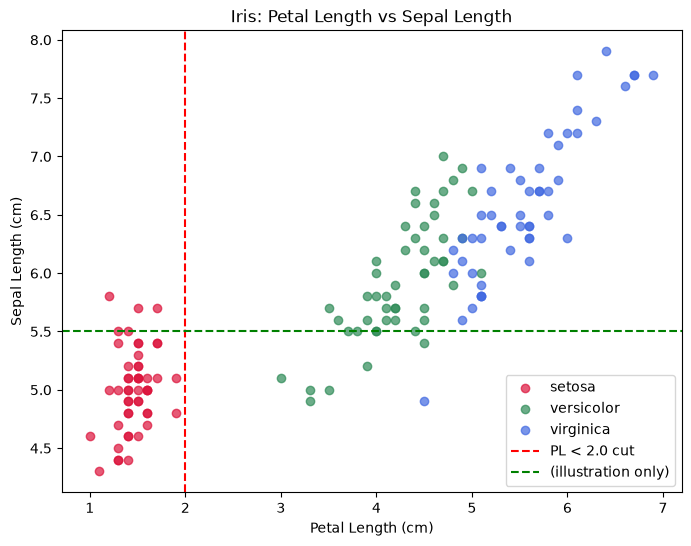

In [79]:
plt.figure(figsize=(8, 6))
colors = {'setosa': 'crimson', 'versicolor': 'seagreen', 'virginica': 'royalblue'}
for sp, c in colors.items():
    subset = df_iris[df_iris['species'] == sp]
    plt.scatter(subset['petal length (cm)'], subset['sepal length (cm)'],
                label=sp, color=c, alpha=0.7)

plt.axvline(x=2.0, color='red', linestyle='--', label='PL < 2.0 cut')
plt.axhline(y=5.5, color='green', linestyle='--', label='(illustration only)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Sepal Length (cm)')
plt.title('Iris: Petal Length vs Sepal Length')
plt.legend()
plt.show()



**Question (answer in the markdown cell below, 2-3 sentences):** Looking at the plot, does the
single cut `PL < 2.0` perfectly separate Setosa from the other two species? What does that tell
you about how "pure" the resulting leaf is?

*Your answer here:*
<textarea rows="10" cols="100"></textarea>



## Part 3 — Entropy: Measuring Disorder

To choose the *best* question to split on, a decision tree needs a way to numerically measure
how "mixed up" a set of labels is. That measure is called **Entropy** — borrowed from physics,
where it measures disorder (think ice → water → vapor: molecules get progressively more free to
move, and entropy increases).

For a dataset $S$ with $c$ classes, entropy is defined as:

$$ E(S) = \sum_{i=1}^{c} -p_i \log_2(p_i) $$

where $p_i$ is the fraction (probability) of class $i$ in $S$.

**Key properties:**
1. More uncertainty → higher entropy.
2. For a **2-class** problem: entropy ranges from **0** (completely pure) to **1** (a perfect 50/50 mix).
3. For **more than 2 classes**, minimum entropy is still 0, but the maximum can exceed 1.
4. You can use $\log_2$ or $\log_e$ — the number itself doesn't matter, only that lower entropy = smaller number and higher entropy = larger number consistently.

### Worked example
Suppose a dataset has 5 examples with labels `[Yes, No, Yes, No, No]` → 2 "Yes", 3 "No".

$$ E(D) = -\frac{2}{5}\log_2\left(\frac{2}{5}\right) - \frac{3}{5}\log_2\left(\frac{3}{5}\right) \approx 0.97 $$

### TODO 3.1 — Implement the entropy function

Complete `entropy()` below. It should work for **any** number of classes, not just two.


In [80]:

def entropy(labels):
    '''
    Compute the Shannon entropy (base 2) of a list/array of class labels.

    Parameters
    ----------
    labels : list or array-like of class labels, e.g. ['Yes','No','Yes']

    Returns
    -------
    float : entropy value >= 0
    '''
    labels = pd.Series(labels)

    # TODO:
    # 1. Get the probability p_i of each unique class (value_counts(normalize=True) is handy)
    # 2. Apply the formula E(S) = sum( -p_i * log2(p_i) )
    # 3. Return the sum
      # Get the probability of each unique class
    probabilities = labels.value_counts(normalize=True)

    # Compute entropy
    """
    entropy = 0
    for p in probabilities:
        entropy += -p * np.log2(p)
    """

    entropy = -(probabilities * np.log2(probabilities)).sum()
    return entropy
                


# ---- sanity checks (do not edit) ----
print("Entropy of ['Yes','No','Yes','No','No'] =", entropy(['Yes','No','Yes','No','No']))
print("Expected approx: 0.97")

print("Entropy of a pure set ['Yes','Yes','Yes'] =", entropy(['Yes','Yes','Yes']))
print("Expected: 0.0")

print("Entropy of perfectly balanced 2-class set ['Yes','No'] =", entropy(['Yes','No']))
print("Expected: 1.0")


Entropy of ['Yes','No','Yes','No','No'] = 0.9709505944546686
Expected approx: 0.97
Entropy of a pure set ['Yes','Yes','Yes'] = -0.0
Expected: 0.0
Entropy of perfectly balanced 2-class set ['Yes','No'] = 1.0
Expected: 1.0



### TODO 3.2 — Which dataset is more "spread out"?

Below are two tiny made-up datasets of house prices (in some currency unit). Plot a histogram
of the `Price` column for both and, in the markdown cell underneath, say which one you think has
higher entropy and why (hint: entropy for continuous data is related to how *peaked* vs *spread
out* the distribution is a sharply peaked distribution is easier to predict, hence lower
entropy).


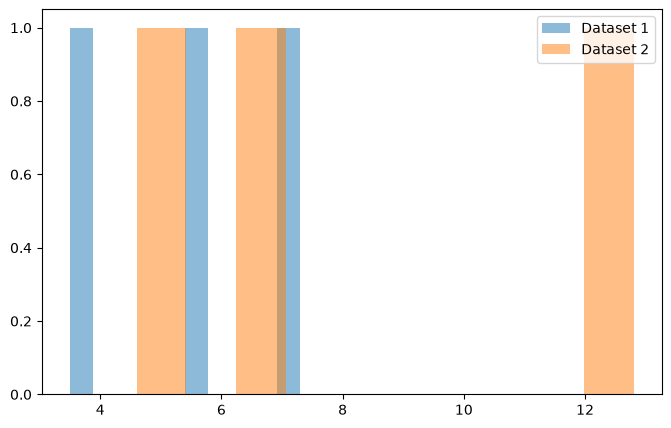

In [81]:

dataset_1 = pd.DataFrame({
    'Area': [1200, 1800, 1400],
    'BuiltIn': [1999, 2001, 2000],
    'Price': [3.5, 5.6, 7.3]
})

dataset_2 = pd.DataFrame({
    'Area': [2200, 800, 1100],
    'BuiltIn': [1989, 2018, 2005],
    'Price': [4.6, 6.5, 12.8]
})

# TODO: plot histograms (or KDE plots) of the 'Price' column for both datasets on the same axes.
# Tip: plt.hist(dataset_1['Price'], alpha=0.5, label='Dataset 1')
#      plt.hist(dataset_2['Price'], alpha=0.5, label='Dataset 2')
plt.hist(dataset_1['Price'], alpha=0.5, label='Dataset 1')
plt.hist(dataset_2['Price'], alpha=0.5, label='Dataset 2')
plt.legend()
plt.show()



*Your answer here: which dataset has higher entropy, and why?*



## Part 4 — Information Gain

**Information Gain (IG)** measures how much entropy *decreases* after splitting a dataset on a
particular feature. It's the metric a decision tree uses to pick the best feature at every node:

$$ \text{IG} = E(\text{Parent}) - \text{WeightedAverage}\big(E(\text{Children})\big) $$

The feature that gives the **highest** Information Gain is chosen for the split.

### The PlayTennis dataset

We'll use the classic "Play Tennis" dataset: given weather conditions, predict whether tennis
was played.


In [82]:
play_tennis = pd.DataFrame({
    'Outlook':  ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast',
                 'Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy'],
    'Temp':     ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                 'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Windy':    [False,True,False,False,False,True,True,
                 False,False,False,True,True,False,True],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes',
                   'No','Yes','Yes','Yes','Yes','Yes','No']
})

play_tennis


,Outlook,Temp,Humidity,Windy,PlayTennis
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes
5,Rainy,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rainy,Mild,Normal,False,Yes



### Worked example — splitting on `Outlook`

**Step 1: Entropy of the parent** (all 14 rows: 9 "Yes", 5 "No")

$$ E(\text{Parent}) = -\frac{9}{14}\log_2\left(\frac{9}{14}\right) - \frac{5}{14}\log_2\left(\frac{5}{14}\right) \approx 0.94 $$

**Step 2: Entropy of each child** (i.e., each value of `Outlook`)

- `E(Sunny)` (2 Yes, 3 No) ≈ 0.97
- `E(Overcast)` (5 Yes, 0 No) = 0 → this is a **pure** leaf node already!
- `E(Rainy)` (3 Yes, 2 No) ≈ 0.97

**Step 3: Weighted average entropy of children**

$$ \frac{5}{14}(0.97) + \frac{4}{14}(0) + \frac{5}{14}(0.97) \approx 0.69 $$

**Step 4: Information Gain**

$$ \text{IG(Outlook)} = 0.94 - 0.69 = 0.25 $$

### TODO 4.1 — Write a reusable Information Gain function

Complete the two functions below, then use them to compute the Information Gain for
`Outlook`, `Temp`, `Humidity`, and `Windy`. Whichever column gives the **highest** IG is the one
the tree should split on first (the root node).


In [83]:
def weighted_child_entropy(df, feature_col, target_col):
    '''
    Compute the weighted average entropy of the children created by
    splitting df on feature_col.
    '''
    total = len(df)
    weighted_entropy = 0.0
    # TODO: for each unique value of feature_col:
    #   1. get the subset of df where feature_col == value
    #   2. compute its entropy on target_col using entropy() from Part 3
    #   3. weight it by (size of subset / total) and add to weighted_entropy
    return weighted_entropy


def information_gain(df, feature_col, target_col):
    '''
    Compute Information Gain from splitting df on feature_col.
    '''
    parent_entropy = entropy(df[target_col])
    child_entropy = weighted_child_entropy(df, feature_col, target_col)
    # TODO: return IG = parent_entropy - child_entropy
    pass


# ---- check against the worked example (do not edit) ----
ig_outlook = information_gain(play_tennis, 'Outlook', 'PlayTennis')
print(f"IG(Outlook)  = {ig_outlook:.2f}  (expected approx 0.25)")


TypeError: unsupported format string passed to NoneType.__format__

In [ ]:

# TODO: compute Information Gain for the remaining columns and print them all
ig_temp = information_gain(play_tennis, 'Temp', 'PlayTennis')
ig_humidity = information_gain(play_tennis, 'Humidity', 'PlayTennis')
ig_windy = information_gain(play_tennis, 'Windy', 'PlayTennis')

print(f"IG(Outlook)  = {ig_outlook:.3f}")
print(f"IG(Temp)     = {ig_temp:.3f}")
print(f"IG(Humidity) = {ig_humidity:.3f}")
print(f"IG(Windy)    = {ig_windy:.3f}")

# TODO: print which column should be chosen as the ROOT NODE (highest IG)



**Reflection:** Once a leaf node's entropy hits 0 (like `Overcast` above), the algorithm stops
splitting that branch — there's nothing left to gain. This recursive "pick the best feature,
split, repeat on each child" process (using a greedy, top-down search) is exactly how a full
decision tree is grown.



## Part 5 — Splitting on Numerical Features

Everything above used categorical features (`Sunny`/`Rainy`, `Student`/`Programmer`). What about
numeric columns like `Petal Length`?

The trick: for a numeric column, the tree tries candidate **threshold** values (e.g., `PL < 1.5`,
`PL < 2.0`, `PL < 2.5`, ...) and computes the Information Gain **as if** that threshold were a
yes/no question, exactly like before. Whichever threshold gives the highest IG is used for that
split. This is why decision trees can carve up numeric feature space into rectangular regions
(hyper-cuboids), as we saw in Part 2.

### TODO 5.1 — Try a threshold yourself

Using the `df_iris` DataFrame from Part 2, compute the Information Gain of splitting on
`petal length (cm) < 2.0` versus the 3-class `species` target.

Hint: create a new temporary column that is `True`/`False` based on the threshold, then reuse
your `information_gain` function.


In [ ]:

# TODO:
# 1. Create a temporary boolean column, e.g. df_iris['PL_lt_2'] = df_iris['petal length (cm)'] < 2.0
# 2. Call information_gain(df_iris, 'PL_lt_2', 'species')
# 3. Print the result




**Discussion question:** Why do you think `2.0` might be a good threshold for Petal Length,
based on the scatter plot you made in Part 2? (No need to try every possible threshold by hand —
in Part 6, `scikit-learn` will search over all of them automatically.)



## Part 6 — Building a Real Decision Tree with `scikit-learn`

Doing entropy/IG calculations by hand does not scale to real datasets with many features and
rows. In practice we use a library. We'll use the full **Iris dataset** (4 features, 3 classes,
150 rows).

### Step 1: Load and split the data


In [ ]:

X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (105, 4)  Test size: (45, 4)



### TODO 6.1 — Train the classifier

Create a `DecisionTreeClassifier` using `criterion='entropy'` (so it uses exactly the Information
Gain metric from Part 4), fit it on the training data, and print its accuracy on the test set.


In [ ]:

# TODO:
# 1. Create clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# 2. Fit it on X_train, y_train
# 3. Predict on X_test -> y_pred
# 4. Compute and print accuracy_score(y_test, y_pred)
"""
clf = None      # replace
y_pred = None   # replace
"""
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Test accuracy: {accuracy:.2%}")

# Create the classifier
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 93.33%



### Step 2: Visualize the tree

Run the cell below (after completing TODO 6.1) to see the actual tree your model learned —
compare its first split to what you might expect from Part 2/5.


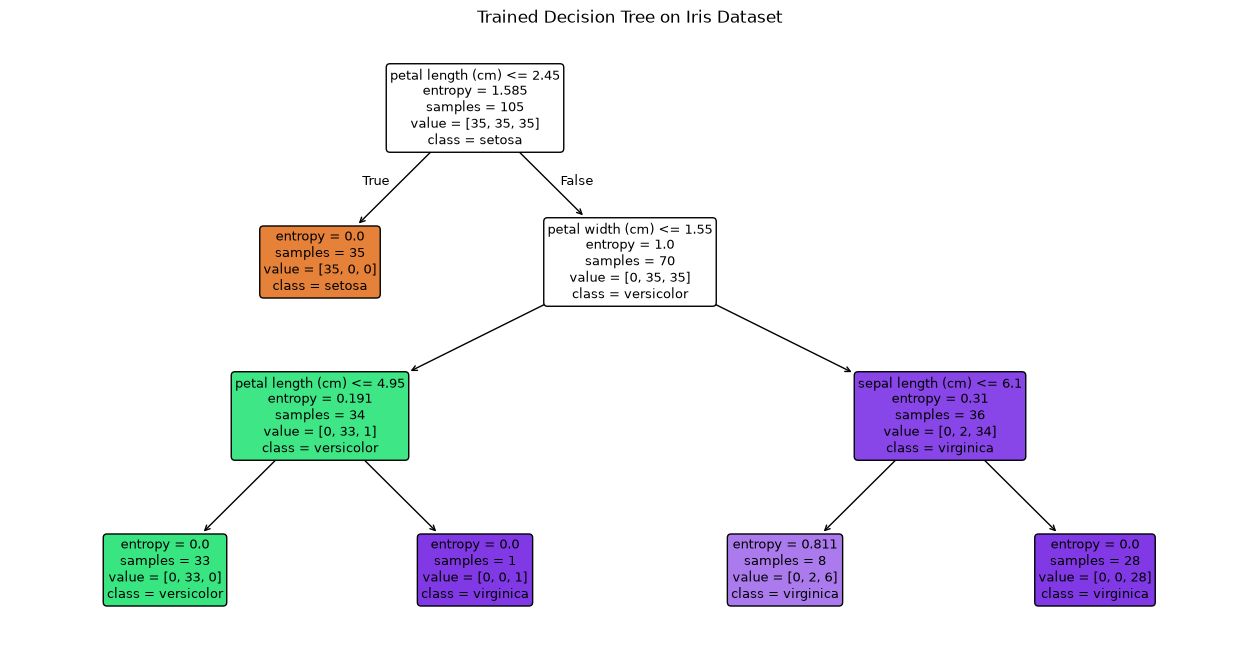

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Trained Decision Tree on Iris Dataset")
plt.show()


### Step 3: Confusion Matrix and Classification Report

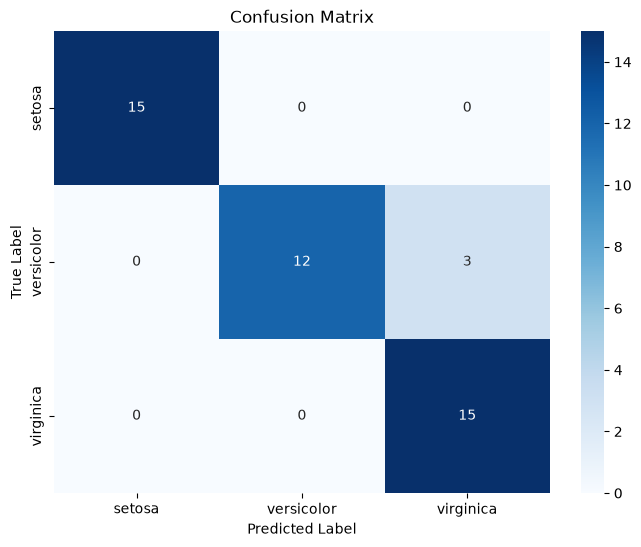

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",   # or "ovo"
    average="weighted"
)

f1 = f1_score(y_test, y_pred, average="weighted")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

print(f"AUC-ROC: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45

AUC-ROC: 0.9600
F1 Score: 0.9327



### TODO 6.2 — Read the tree

Look at the plotted tree and answer in the cell below:
1. Which feature and threshold does the **root node** split on? Does it match what you found in
   Part 5?
2. What is the entropy value shown in a leaf node that classifies perfectly? What does that
   confirm from Part 3?

*Your answers here:*


### Feature Importance

`scikit-learn` can tell you which features contributed most to reducing entropy across the whole
tree (this is closely related to total Information Gain). Print `clf.feature_importances_`
alongside the feature names, sorted from most to least important.


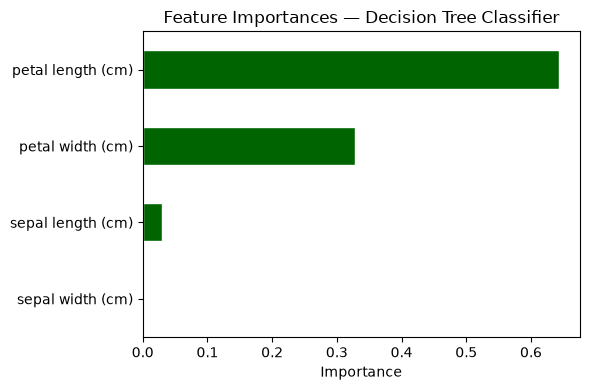

In [ ]:
importances_cls = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(6, 4))

importances_cls.plot(kind="barh", color="darkgreen", edgecolor="white")
plt.title("Feature Importances — Decision Tree Classifier")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Accuracy vs. Tree Depth


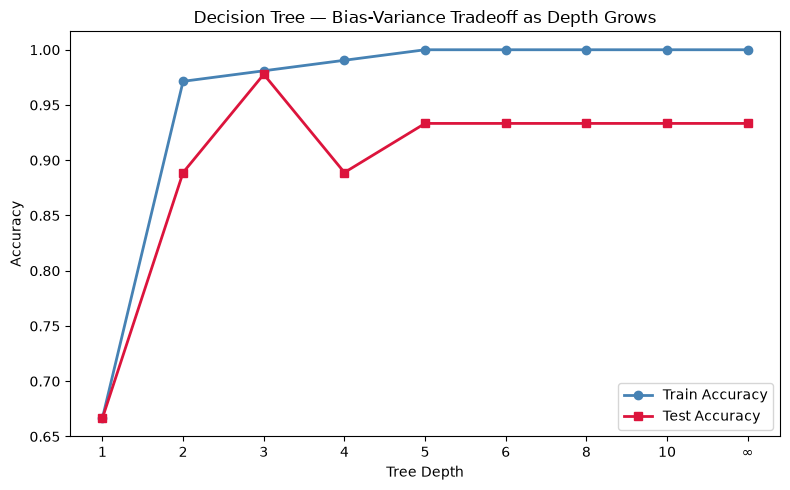

In [ ]:
depths   = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_accuracy, test_accuracy = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accuracy.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, dt.predict(X_test)))

depth_labels = [str(d) if d is not None else "∞" for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_accuracy, "o-", color="steelblue",  linewidth=2, label="Train Accuracy")
plt.plot(depth_labels, test_accuracy,  "s-", color="crimson",    linewidth=2, label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree — Bias-Variance Tradeoff as Depth Grows")
plt.legend()
plt.tight_layout()
plt.show()


## Reflection

Decision trees are one of the few ML models that require **minimal data preparation** — no need
to normalize or standardize features, since splits only compare values within a single column.
Prediction (inference) cost is roughly **logarithmic** in the number of training rows, since you
just walk down the tree.

However, they have known weaknesses:
- **They overfit easily** if grown too deep.
- **They can struggle with imbalanced datasets**, where one class dominates.



In [ ]:
path = clf.cost_complexity_pruning_path(X_train,y_train)
path

{'ccp_alphas': array([0.        , 0.04431751, 0.06198791, 0.49854958, 0.91829583]),
 'impurities': array([0.06181167, 0.10612918, 0.16811709, 0.66666667, 1.5849625 ])}

In [ ]:
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.04431751, 0.06198791, 0.49854958, 0.91829583])

In [ ]:
pruned_models = []
for alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(
        criterion='entropy',
        random_state=42,
        ccp_alpha=alpha
    )
    pruned_model.fit(X_train,y_train)
    pruned_models.append(pruned_model)

In [85]:
best_accuracy = 0
best_pruned_model = None

for model in  pruned_models:
    acc = model.score(X_test,y_test)
    if acc > best_accuracy:
        best_accuracy = acc
        best_pruned_model = model
print(f"Best Accuracy: {best_accuracy*100:.2f}%")

Best Accuracy: 93.33%


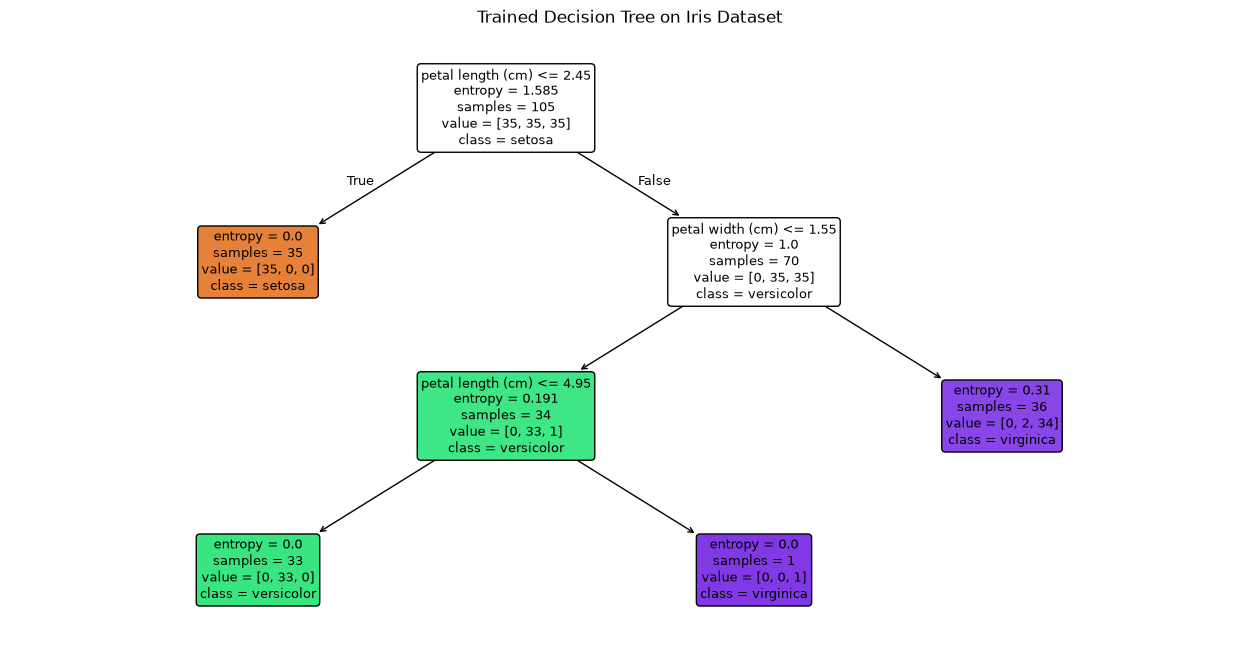

: 

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(best_pruned_model, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Best Pruned Model")
plt.show()
